# This model estimate the bid-ask spread

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import matplotlib.pyplot as plt

In [13]:
# Feature
def RollModel(data):
    result = data[['Datetime']].copy()
    result['Delta_P_t'] = data['Close'].diff()
    result['Delta_P_shift'] = result['Delta_P_t'].shift()
    
    window_size = 60
    
    result['spread_roll'] = (
        result['Delta_P_t'].
                   rolling(window=window_size).cov(result['Delta_P_shift']).
                   apply(lambda x: max(0,(-x))**0.5)
    )
    
    return result[['Datetime','spread_roll']]

In [14]:
WFC = yf.download('WFC', interval='1m', period='1d')
WFC.columns = WFC.columns.droplevel(1)
WFC.reset_index(inplace=True)
WFC.head()

[*********************100%***********************]  1 of 1 completed


Price,Datetime,Adj Close,Close,High,Low,Open,Volume
0,2024-11-01 13:30:00+00:00,64.940002,64.940002,65.230003,64.940002,65.220001,370022
1,2024-11-01 13:31:00+00:00,65.080002,65.080002,65.160004,65.070000,65.129997,46933
2,2024-11-01 13:32:00+00:00,65.470001,65.470001,65.480003,65.224998,65.224998,40668
3,2024-11-01 13:33:00+00:00,65.531502,65.531502,65.531502,65.410004,65.462997,42069
4,2024-11-01 13:34:00+00:00,65.230003,65.230003,65.580002,65.190002,65.519997,43913


The proportion of positive c is 0.45478036175710596


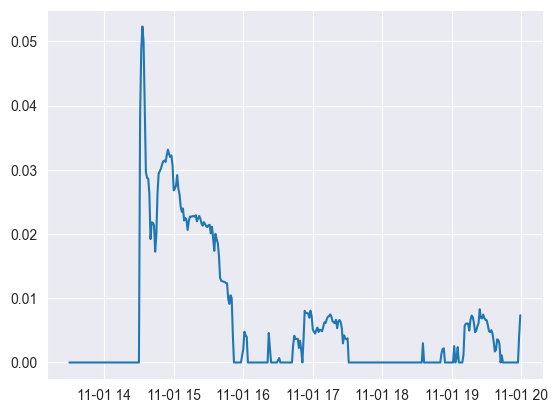

In [16]:
result = RollModel(WFC)
print('The proportion of positive c is',sum(result['spread_roll']>0)/result.shape[0])
plt.figure()
plt.plot(result['Datetime'],result['spread_roll'])